# Proyecto 1 
 Juan Camilo Gómez-202220238
 
 Jerónimo Rueda-202223775

### Librerias


In [64]:
   
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  

## Datos

In [65]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    format="%d/%m/%Y",
    errors="coerce"
)
df["estu_fechanacimiento"].isna().sum()

#df["estu_fechanacimiento"].describe()

#df.loc[641382, ["estu_fechanacimiento","periodo"]]

df["año"]=df["periodo"].astype(str).str[:4]



ti_menoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 17).astype(str),format="%d/%m/%Y")

cc_mayoresedad = pd.to_datetime("01/01/" + (df["año"].astype(int) - 18).astype(str),format="%d/%m/%Y")

reemplazofechanac = df["estu_fechanacimiento"].isna() | (df["estu_fechanacimiento"].dt.year == 1900)

df.loc[reemplazofechanac, "estu_fechanacimiento"] = np.where(
    df.loc[reemplazofechanac, "estu_tipodocumento"].eq("TI"),
    ti_menoresedad.loc[reemplazofechanac],
    cc_mayoresedad.loc[reemplazofechanac]
)
#df.loc[df["estu_fechanacimiento"].isna(), "estu_fechanacimiento"] = np.where(df["estu_tipodocumento"] == "TI",ti_menoresedad,cc_mayoresedad)
#df[df["estu_fechanacimiento"].isna()][["estu_fechanacimiento","periodo","estu_tipodocumento"]][["periodo","estu_tipodocumento"]].value_counts() 

df=df[df["año"].astype(int)>2014]

#print(df["estu_fechanacimiento"].sort_values().head(50))
#print(df["estu_fechanacimiento"].sort_values().tail(10))

### Atributos

In [66]:
df.shape
print(df["estrato_num"].value_counts())
print(df["fami_estratovivienda"].value_counts())

estrato_num
2.0    87279
1.0    66415
3.0    54964
4.0    16747
5.0     9981
6.0     4515
0.0     2589
Name: count, dtype: int64
fami_estratovivienda
Estrato 2      87279
Estrato 1      66415
Estrato 3      54964
Estrato 4      16747
Estrato 5       9981
Estrato 6       4515
Sin Estrato     2589
Name: count, dtype: int64


# Descripción Breve Estadística

In [67]:
df.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_fechanacimiento,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num
count,254015.000000,2.539480e+05,2.540150e+05,254015.0,254015.000000,254015.000000,253987.000000,253987.000000,253743.000000,253743.000000,254015,253917.00000,254015.000000,254015.000000,254015.000000,254015.000000,254015.000000,242490.000000
mean,20181.644021,2.685301e+11,2.691913e+11,76.0,76200.756975,152570.702486,75.815439,76006.893345,75.808732,76007.118001,2000-06-15 11:29:33.632265856,52.12968,51.250765,50.260615,51.338437,53.505324,258.151491,2.267508
min,20151.000000,1.760010e+11,1.760010e+11,76.0,76001.000000,16659.000000,5.000000,5001.000000,5.000000,5001.000000,1910-03-03 00:00:00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.761090e+11,1.761090e+11,76.0,76001.000000,24430.000000,76.000000,76001.000000,76.000000,76001.000000,1998-10-07 00:00:00,43.00000,42.000000,41.000000,43.000000,46.000000,220.000000,1.000000
50%,20172.000000,1.768921e+11,1.768950e+11,76.0,76001.000000,95083.000000,76.000000,76001.000000,76.000000,76001.000000,2000-05-24 00:00:00,50.00000,51.000000,50.000000,51.000000,53.000000,255.000000,2.000000
75%,20194.000000,3.760010e+11,3.760010e+11,76.0,76364.000000,144931.000000,76.000000,76306.000000,76.000000,76364.000000,2002-11-25 00:00:00,59.00000,59.000000,59.000000,59.000000,61.000000,293.000000,3.000000
max,20224.000000,5.376109e+11,5.376110e+11,76.0,76895.000000,806752.000000,99.000000,99524.000000,95.000000,95001.000000,2022-03-05 00:00:00,100.00000,100.000000,100.000000,100.000000,100.000000,495.000000,6.000000
std,25.287858,9.882207e+10,9.891760e+10,0.0,287.206300,198930.462455,3.265251,3278.166802,3.326545,3336.116728,NaN,13.18046,12.301105,11.962517,10.885795,10.305067,51.656128,1.190088


# Covarianza


In [68]:
#temp=df.drop(index = [1,2,3,4,5], inplace=False)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254015 entries, 0 to 642589
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   periodo                        254015 non-null  int64         
 1   estu_tipodocumento             254015 non-null  object        
 2   estu_consecutivo               254015 non-null  object        
 3   cole_area_ubicacion            254015 non-null  object        
 4   cole_bilingue                  225515 non-null  object        
 5   cole_calendario                254015 non-null  object        
 6   cole_caracter                  249336 non-null  object        
 7   cole_cod_dane_establecimiento  253948 non-null  float64       
 8   cole_cod_dane_sede             254015 non-null  float64       
 9   cole_cod_depto_ubicacion       254015 non-null  int64         
 10  cole_cod_mcpio_ubicacion       254015 non-null  int64         
 11  cole_

## Faltantes

In [70]:
#df.isna().sum()

df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]
x=df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]
reemplazaringles=round((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]/x)*df["punt_matematicas"]+(df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]/x)*df["punt_lectura_critica"]+((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]/5)/x)*df["punt_global"],0)
#print(reemplazaringles

df["punt_ingles"] = df["punt_ingles"].fillna(reemplazaringles)


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [
    df["punt_ingles"] < 27,
    df["punt_ingles"] <= 40,
    df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

# Solo llenar faltantes en desemp_ingles
df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))


categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)
df["año"]=df["periodo"].astype(str).str[:4]

df.isna().sum()


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_22216\1229244985.py:86: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_22216\1229244985.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

## Columnas y Ejemplo

In [71]:
columnas=df.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {df[i][2]}")


Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDÍ
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

# Gráficos de 2 o más variables

## Estratos y Puntajes

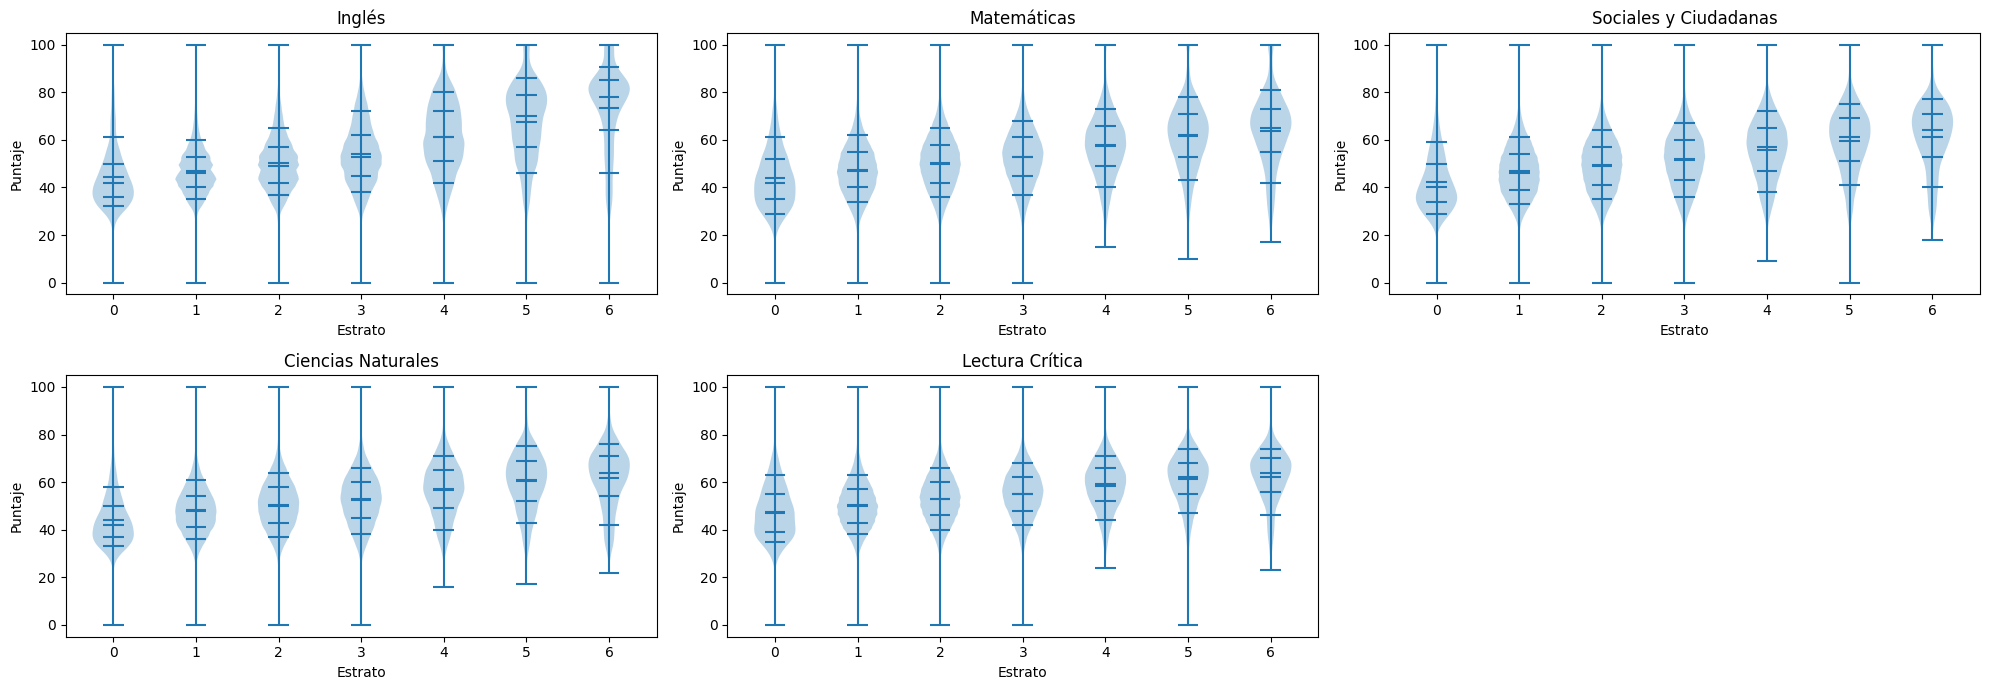

In [72]:


estratos = sorted(df["estrato_num"].dropna().unique())
fig= plt.figure(figsize=(20,7))
ax1= fig.add_subplot(2, 3, 1)
ax2= fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
areas = [
    ("punt_ingles", ax1),
    ("punt_matematicas", ax2),
    ("punt_sociales_ciudadanas", ax3),
    ("punt_c_naturales", ax4),
    ("punt_lectura_critica", ax5),
]
ax1.set_title("Inglés")
ax2.set_title("Matemáticas")
ax3.set_title("Sociales y Ciudadanas")
ax4.set_title("Ciencias Naturales")
ax5.set_title("Lectura Crítica")



for tipo, ax in areas:

    datos = [df.loc[df["estrato_num"] == i, tipo].dropna().values for i in estratos]

    ax.violinplot(datos, showmeans=True, quantiles=[[0.1,0.25,0.5,0.75,0.9]]*len(datos))
    ax.set_xlabel("Estrato")
    ax.set_ylabel("Puntaje")
    ax.set_xticks(np.arange(1, len(estratos) + 1))
    ax.set_xticklabels(estratos)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Estrato')

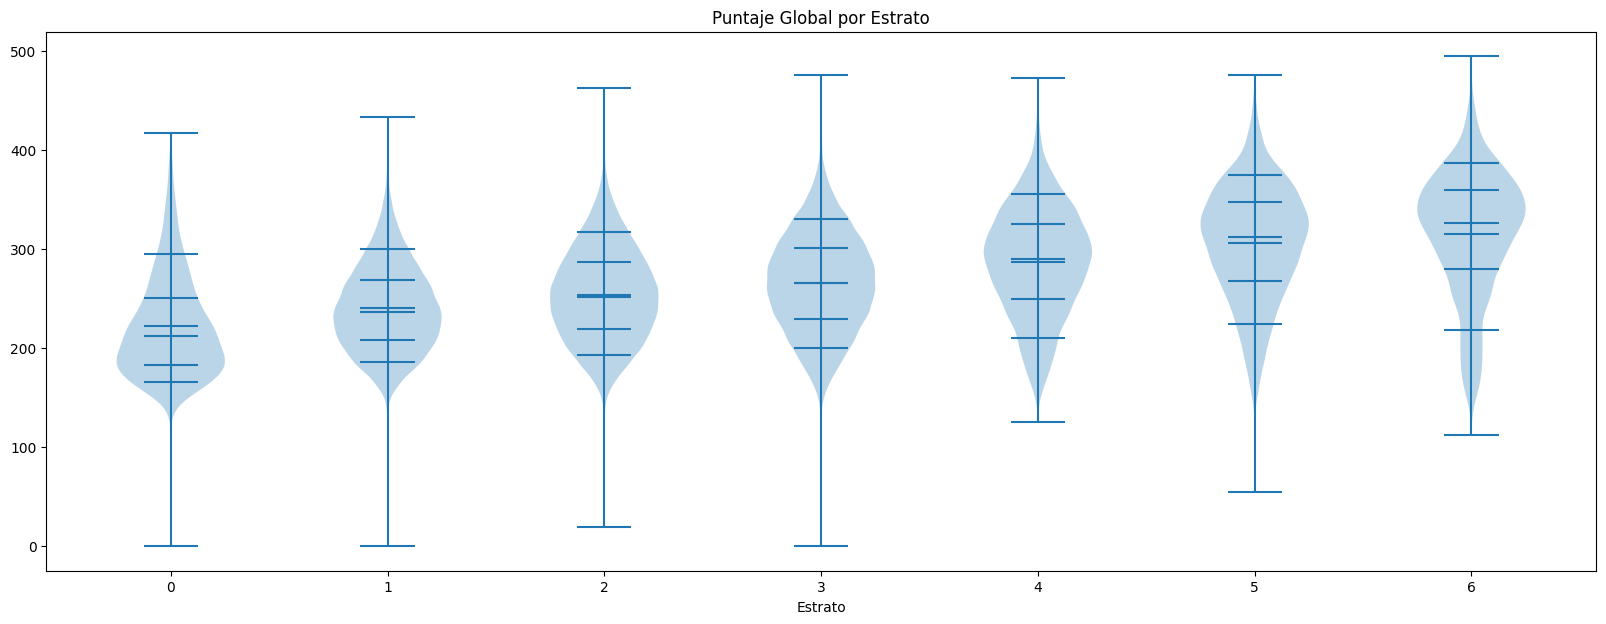

In [73]:
estratos = sorted(df["estrato_num"].dropna().unique())
fig= plt.figure(figsize=(20,7))
ax1= fig.add_subplot(1, 1, 1)
ax1.set_title("Puntaje Global por Estrato")
datos = [df.loc[df["estrato_num"] == i, "punt_global"].dropna().values for i in estratos]
ax1.violinplot(datos, showmeans=True, quantiles=[[0.1,0.25,0.5,0.75,0.9]]*len(datos))
ax1.set_xticks(range(1, len(estratos) + 1))
ax1.set_xticklabels(["0","1","2","3","4","5","6"])
ax1.set_xlabel("Estrato")


### Puntaje con y Sin computador


Text(0.5, 1.0, 'Puntaje Global por Estrato y Computador')

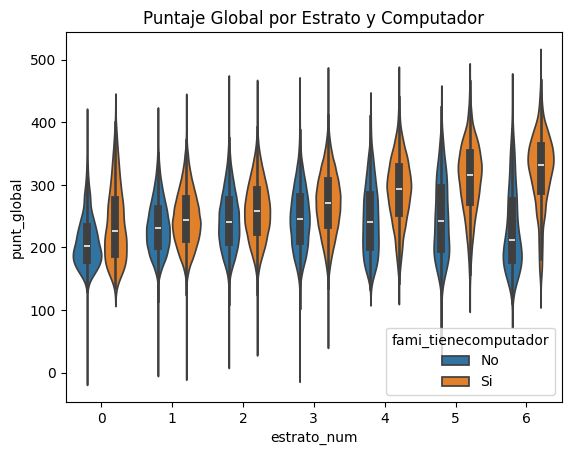

In [74]:
ax=sns.violinplot(data=df, x="estrato_num", y="punt_global", hue="fami_tienecomputador")
ax.set_title("Puntaje Global por Estrato y Computador")

### Puntaje Con y Sin Internet

Text(0.5, 1.0, 'Puntaje Global por Estrato e Internet')

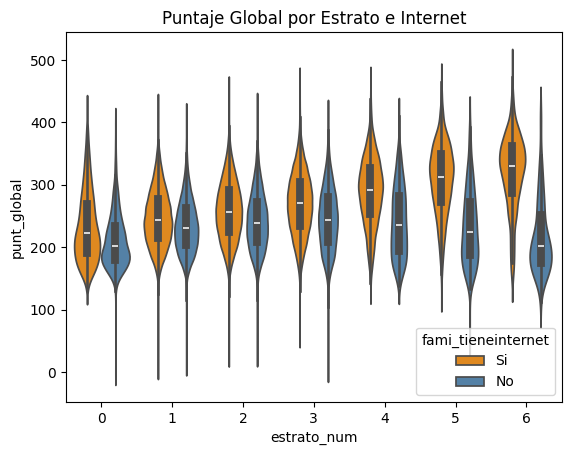

In [75]:
ax=sns.violinplot(data=df, x="estrato_num", y="punt_global", hue="fami_tieneinternet",palette={"Si": "darkorange", "No": "steelblue"})
ax.set_title("Puntaje Global por Estrato e Internet")

## Nacionalidad y Residencia contra Puntajes

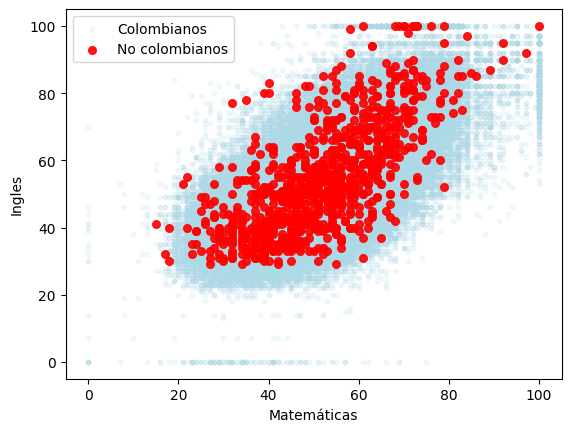

In [76]:
#colombianos=df[df["estu_nacionalidad"]=="COLOMBIA"]
#otra_nacionalidad=df[df["estu_nacionalidad"]!="COLOMBIA"]

#print(colombianos.shape)
#print(otra_nacionalidad.shape)  

tmp = df[["punt_matematicas","punt_ingles","estu_nacionalidad"]].dropna()

col = tmp[tmp["estu_nacionalidad"]=="COLOMBIA"]
ext = tmp[tmp["estu_nacionalidad"]!="COLOMBIA"]

plt.scatter(col["punt_matematicas"], col["punt_ingles"],
            color="lightblue", alpha=0.15, s=10, label="Colombianos")

plt.scatter(ext["punt_matematicas"], ext["punt_ingles"],
            color="red", alpha=0.9, s=30, label="No colombianos")

plt.legend()
plt.xlabel("Matemáticas")
plt.ylabel("Ingles")
plt.show()


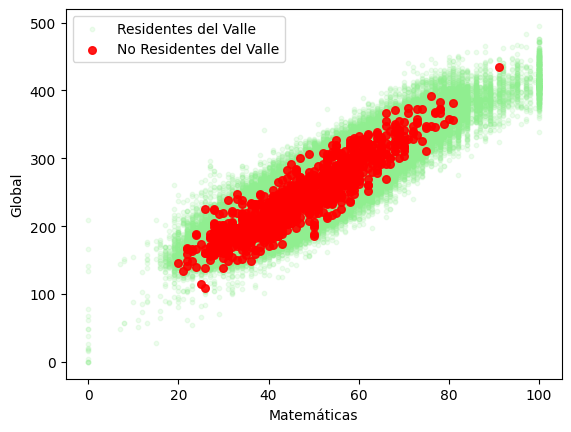

In [77]:
#valle=df[df["estu_cod_reside_depto"]==76]
#otro_dep=df[df["estu_cod_reside_depto"]!=76]

#print(valle.shape)
#print(otro_dep.shape)  

"""
tmp = df[["punt_matematicas","punt_ingles","estu_cod_reside_depto"]].dropna()

valle = tmp[tmp["estu_cod_reside_depto"]==76]
novalle = tmp[tmp["estu_cod_reside_depto"]!=76]

plt.scatter(valle["punt_matematicas"], valle["punt_ingles"],
            color="lightgreen", alpha=0.15, s=10, label="Residentes del Valle")

plt.scatter(novalle["punt_matematicas"], novalle["punt_ingles"],
            color="red", alpha=0.9, s=30, label="No Residentes del Valle")

plt.legend()
plt.xlabel("Matemáticas")
plt.ylabel("Ingles")
plt.show()

"""


tmp = df[["punt_matematicas","punt_global","estu_cod_reside_depto"]].dropna()

valle = tmp[tmp["estu_cod_reside_depto"]==76]
novalle = tmp[tmp["estu_cod_reside_depto"]!=76]

plt.scatter(valle["punt_matematicas"], valle["punt_global"],
            color="lightgreen", alpha=0.15, s=10, label="Residentes del Valle")

plt.scatter(novalle["punt_matematicas"], novalle["punt_global"],
            color="red", alpha=0.9, s=30, label="No Residentes del Valle")

plt.legend()
plt.xlabel("Matemáticas")
plt.ylabel("Global")
plt.show()


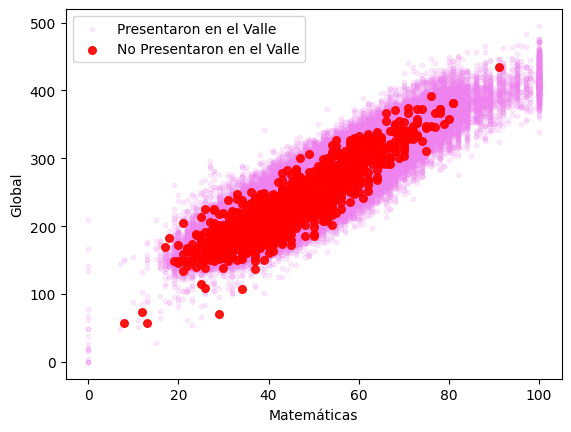

In [78]:
#valle=df[df["estu_depto_presentacion"]=="VALLE"]
#otro_dep=df[df["estu_depto_presentacion"]!="VALLE"]

#print(valle.shape)
#print(otro_dep.shape)  

"""
tmp = df[["punt_matematicas","punt_ingles","estu_depto_presentacion"]].dropna()

valle = tmp[tmp["estu_depto_presentacion"]=="VALLE"]
novalle = tmp[tmp["estu_depto_presentacion"]!="VALLE"]

plt.scatter(valle["punt_matematicas"], valle["punt_ingles"],
            color="violet", alpha=0.15, s=10, label="Presentaron en el Valle")

plt.scatter(novalle["punt_matematicas"], novalle["punt_ingles"],
            color="red", alpha=0.9, s=30, label="No Presentaron en el Valle")

plt.legend()
plt.xlabel("Matemáticas")
plt.ylabel("Ingles")
plt.show()

"""


tmp = df[["punt_matematicas","punt_global","estu_depto_presentacion"]].dropna()

valle = tmp[tmp["estu_depto_presentacion"]=="VALLE"]
novalle = tmp[tmp["estu_depto_presentacion"]!="VALLE"]

plt.scatter(valle["punt_matematicas"], valle["punt_global"],

            color="violet", alpha=0.15, s=10, label="Presentaron en el Valle")

plt.scatter(novalle["punt_matematicas"], novalle["punt_global"],
            color="red", alpha=0.9, s=30, label="No Presentaron en el Valle")

plt.legend()
plt.xlabel("Matemáticas")
plt.ylabel("Global")
plt.show()



## Tipo de Jornada y de Colegio contra Puntajes

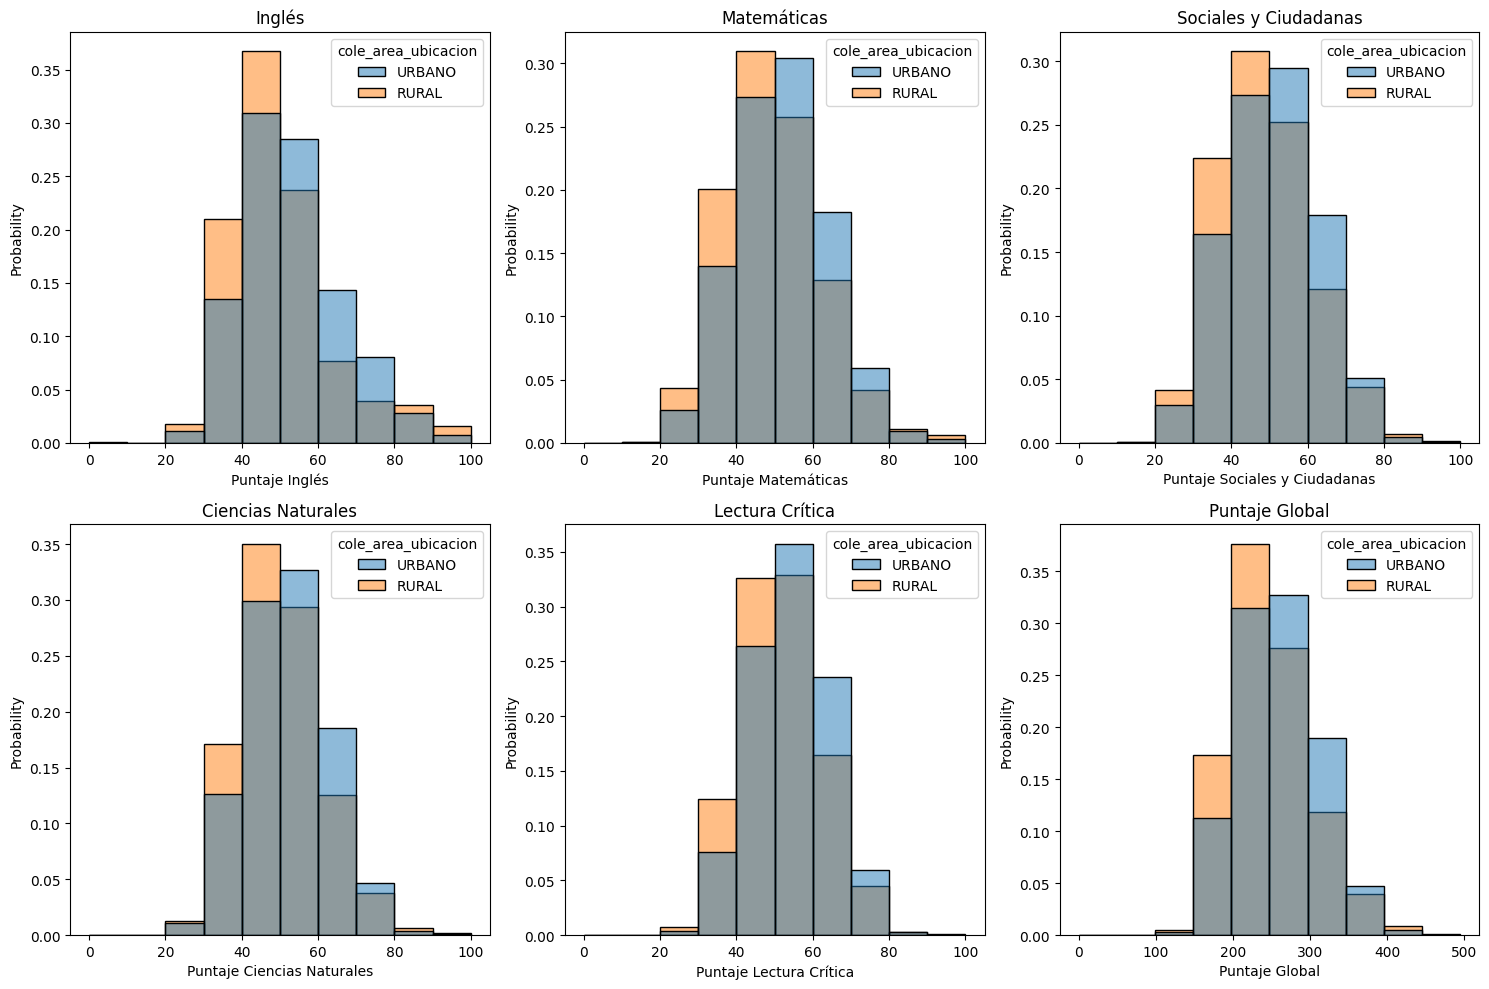

In [79]:

puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(data=df, x=puntajes[i], bins=10, ax=axes[i], hue="cole_area_ubicacion",stat="probability",common_norm=False)
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")


plt.tight_layout()
plt.show()

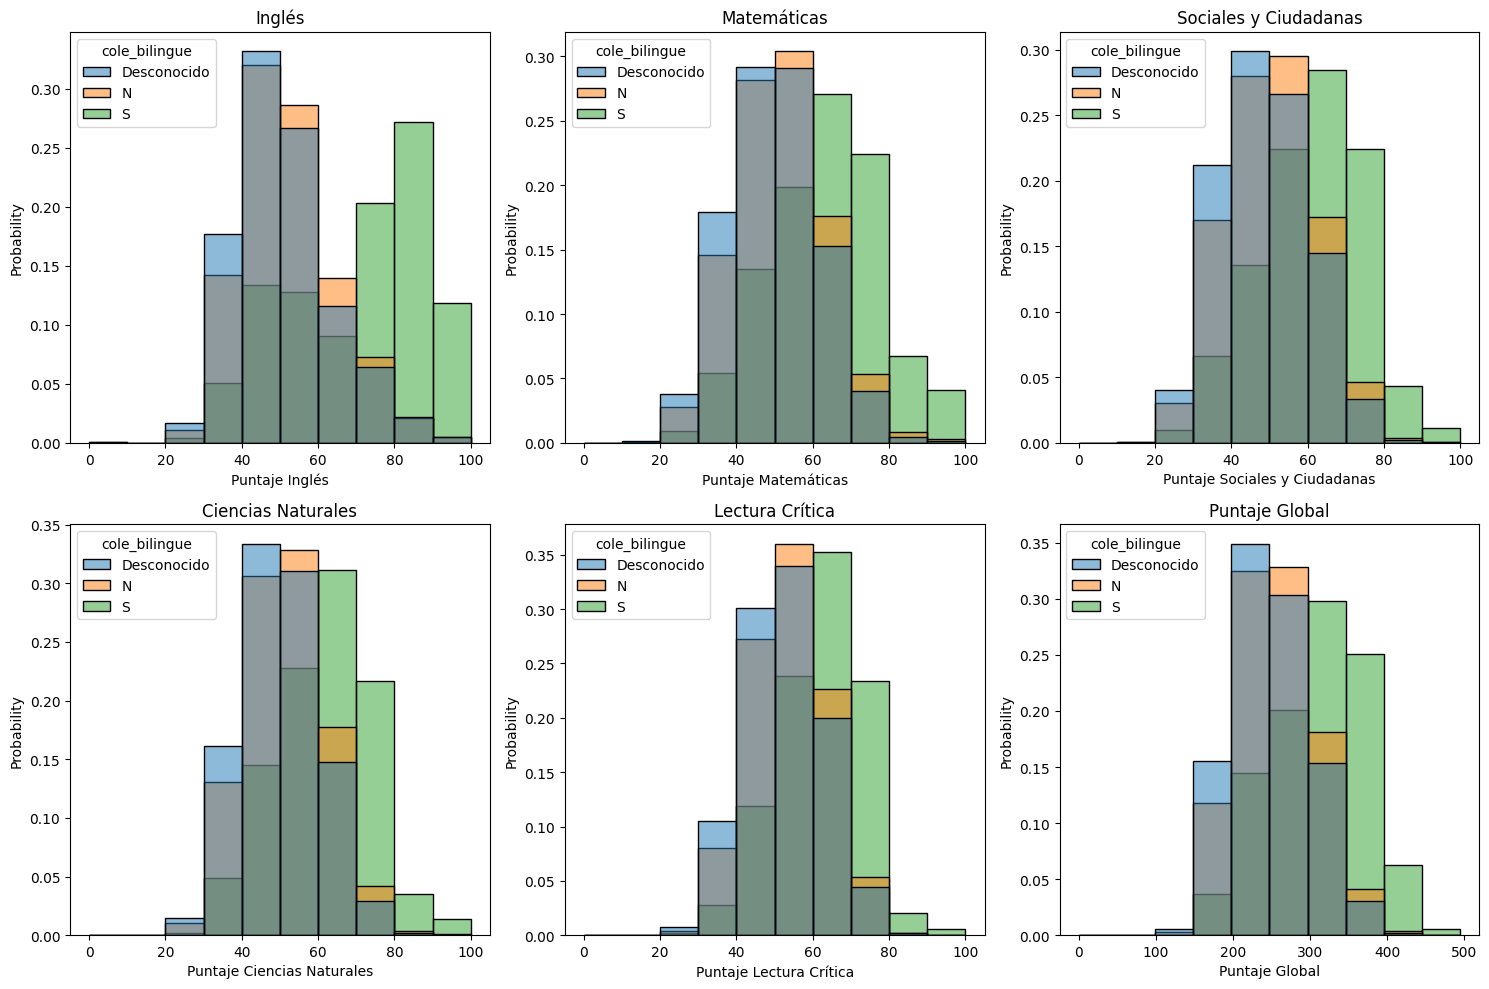

In [80]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(data=df, x=puntajes[i], bins=10, ax=axes[i], hue="cole_bilingue",stat="probability",common_norm=False)
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")


plt.tight_layout()
plt.show()

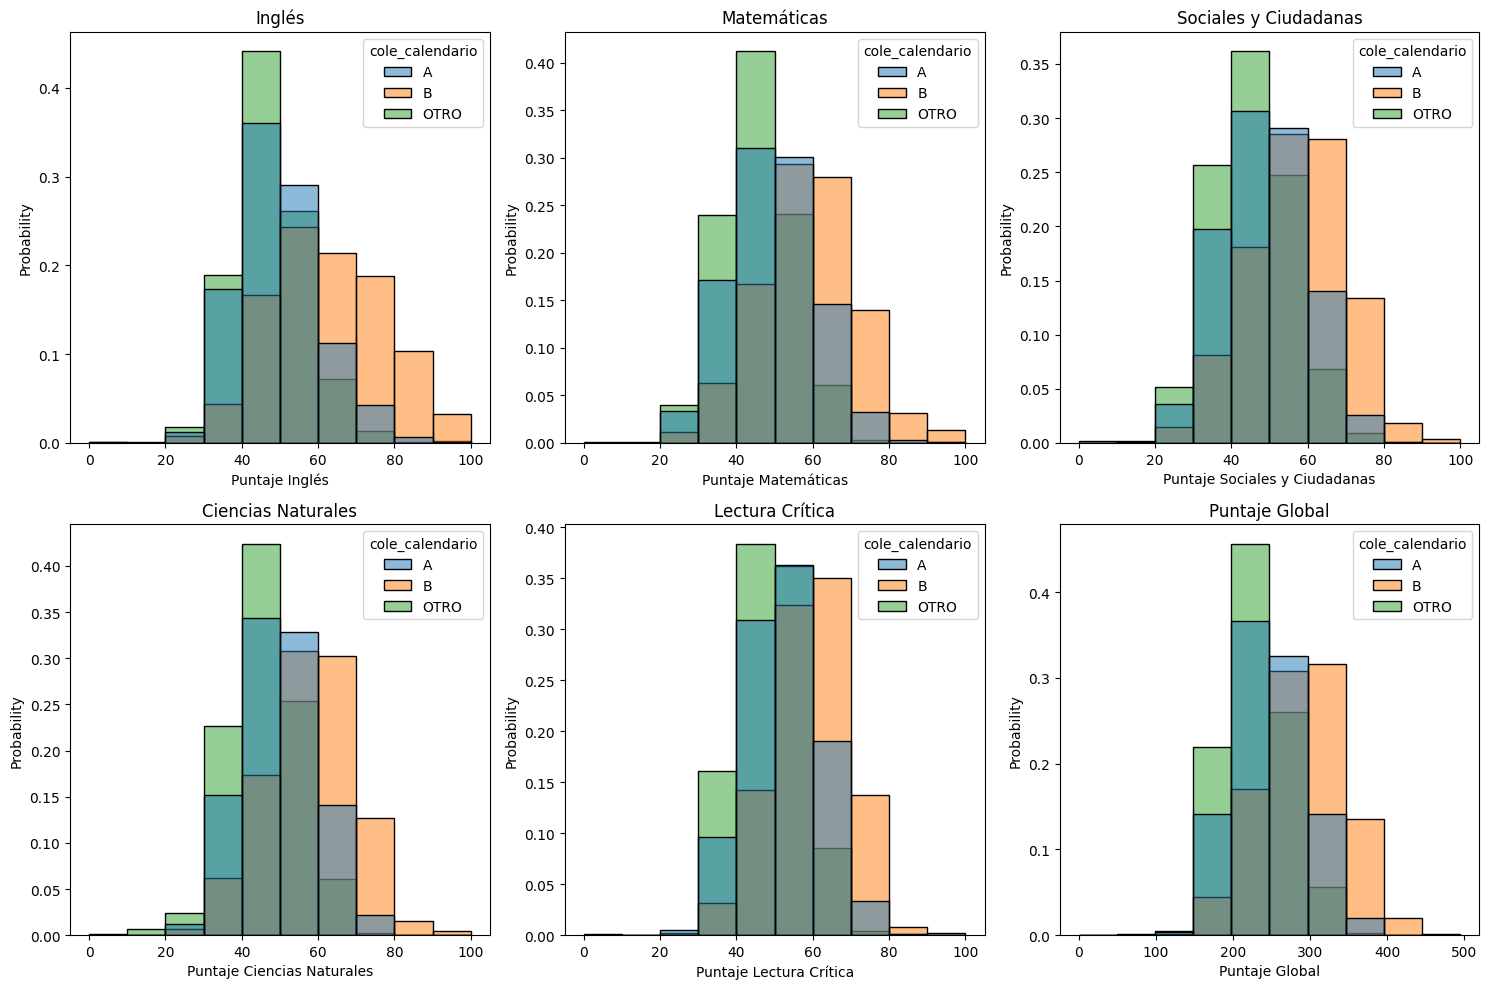

In [81]:

puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(data=df, x=puntajes[i], bins=10, ax=axes[i], hue="cole_calendario",stat="probability",common_norm=False)
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")


plt.tight_layout()
plt.show()

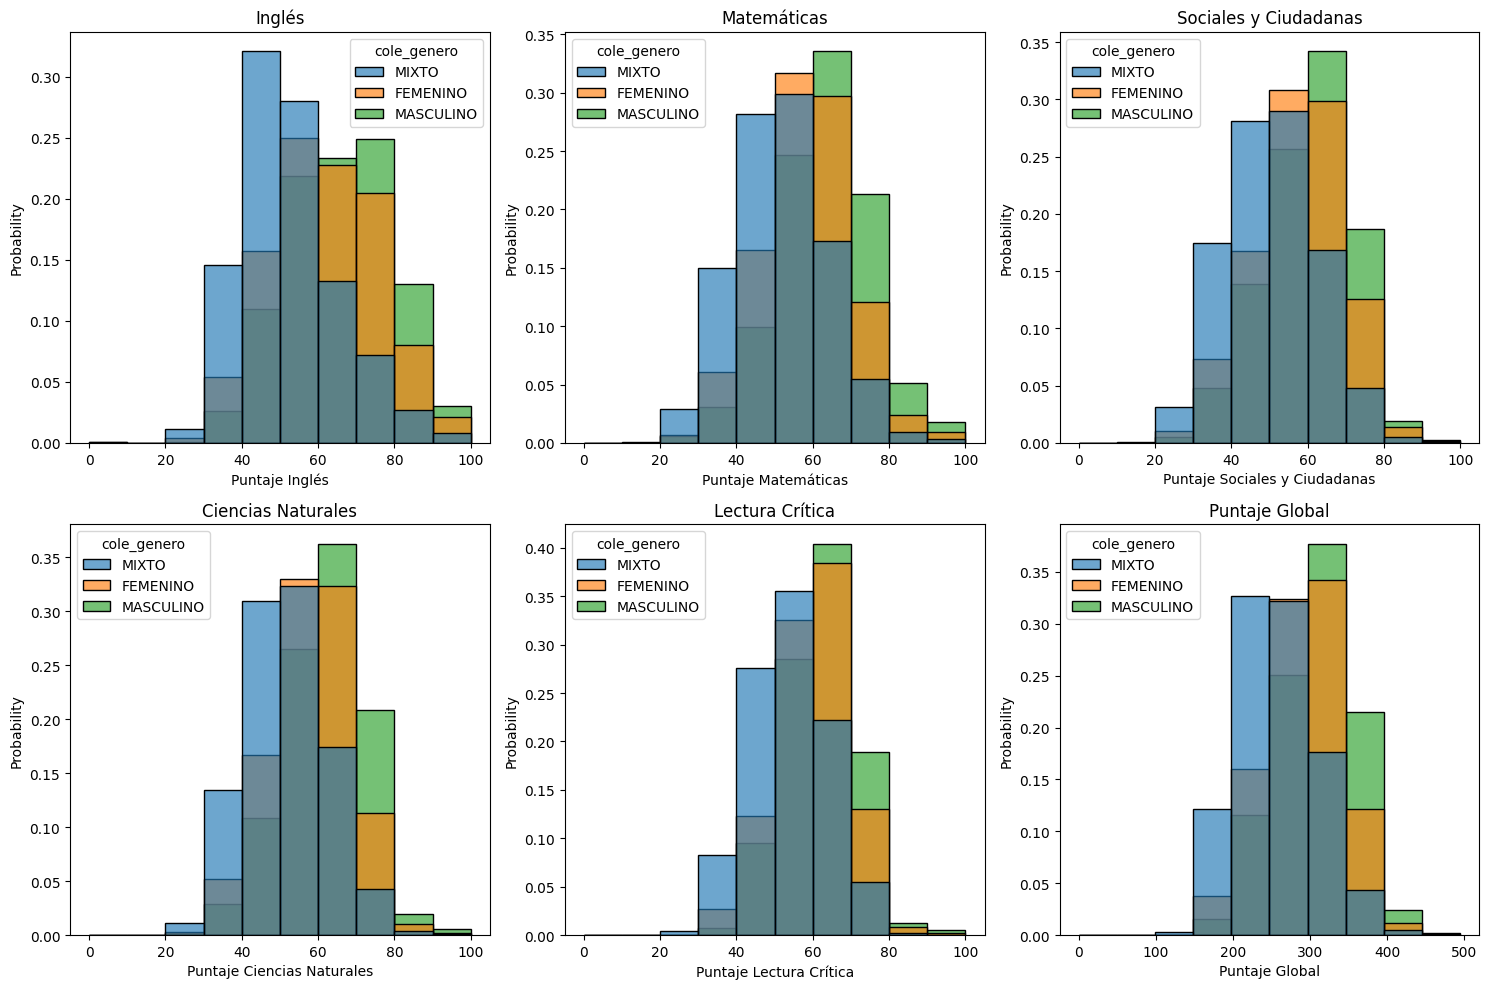

In [82]:

puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(data=df, x=puntajes[i], bins=10, ax=axes[i], hue="cole_genero",stat="probability",common_norm=False, alpha=0.65)
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")


plt.tight_layout()
plt.show()

## Por Municipios

In [83]:
municipios= df[["año","estu_fechanacimiento","cole_mcpio_ubicacion","punt_ingles","punt_matematicas",
                                      "punt_sociales_ciudadanas","punt_c_naturales",
                                      "punt_lectura_critica","punt_global"]]

def normalizar(s):
    return (s.str.normalize("NFKD")
                .str.encode("ascii","ignore")
                .str.decode("utf-8").str.upper()
                .str.strip())





municipios["cole_mcpio_ubicacion"] = (
    df["cole_mcpio_ubicacion"]
    .pipe(normalizar))
municipios["cole_mcpio_ubicacion"] = municipios["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")

mapazonas= {
    # Zona Pacífico 
    "BUENAVENTURA": "Pacífico",

    # Zona Centro
    "CALIMA EL DARIEN": "Centro",
    "YOTOCO": "Centro",
    "SAN PEDRO": "Centro",
    "GUADALAJARA DE BUGA": "Centro",   
    "BUGA": "Centro",                  
    "GUACARI": "Centro",
    "GINEBRA": "Centro",
    "EL CERRITO": "Centro",

    # Zona Sur 
    "DAGUA": "Sur",
    "LA CUMBRE": "Sur",
    "VIJES": "Sur",
    "YUMBO": "Sur",
    "CALI": "Sur",
    "PALMIRA": "Sur",
    "CANDELARIA": "Sur",
    "PRADERA": "Sur",
    "FLORIDA": "Sur",
    "JAMUNDI": "Sur",
    "RESTREPO": "Sur",

    # Zona Norte
    "ALCALA": "Norte",
    "ULLOA": "Norte",
    "CARTAGO": "Norte",
    "ANSERMANUEVO": "Norte",
    "EL AGUILA": "Norte",
    "EL CAIRO": "Norte",
    "VERSALLES": "Norte",
    "ARGELIA": "Norte",
    "TORO": "Norte",
    "OBANDO": "Norte",
    "LA VICTORIA": "Norte",
    "LA UNION": "Norte",
    "ROLDANILLO": "Norte",
    "ZARZAL": "Norte",
    "BOLIVAR": "Norte",
    "TRUJILLO": "Norte",
    "RIOFRIO": "Norte",
    "EL DOVIO": "Norte",
    "ANDALUCIA": "Norte",
    "BUGALAGRANDE": "Norte",
    "TULUA": "Norte",
    "SEVILLA": "Norte",
    "CAICEDONIA": "Norte",
}

municipios["Zona"] = municipios["cole_mcpio_ubicacion"].map(mapazonas)
#print(municipios.groupby("Zona").size())
#municipios[municipios["Zona"].isna()]
municipios.head()

municipios["año"] = municipios["año"].astype(int)
municipios["estu_fechanacimiento"] = municipios["estu_fechanacimiento"].astype("datetime64[ns]")

municipios_agg = (municipios
    .groupby(["cole_mcpio_ubicacion", "año","estu_fechanacimiento"], as_index=False)
    .agg(**{col: (col, "mean") for col in puntajes})
    
)
municipios_agg["año"]



C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_22216\1026951910.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  municipios["cole_mcpio_ubicacion"] = (
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_22216\1026951910.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  municipios["cole_mcpio_ubicacion"] = municipios["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_22216\1026951910.py:73: SettingWit

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
95788    2022
95789    2022
95790    2022
95791    2022
95792    2022
Name: año, Length: 95793, dtype: int64

## Por años de nacimiento

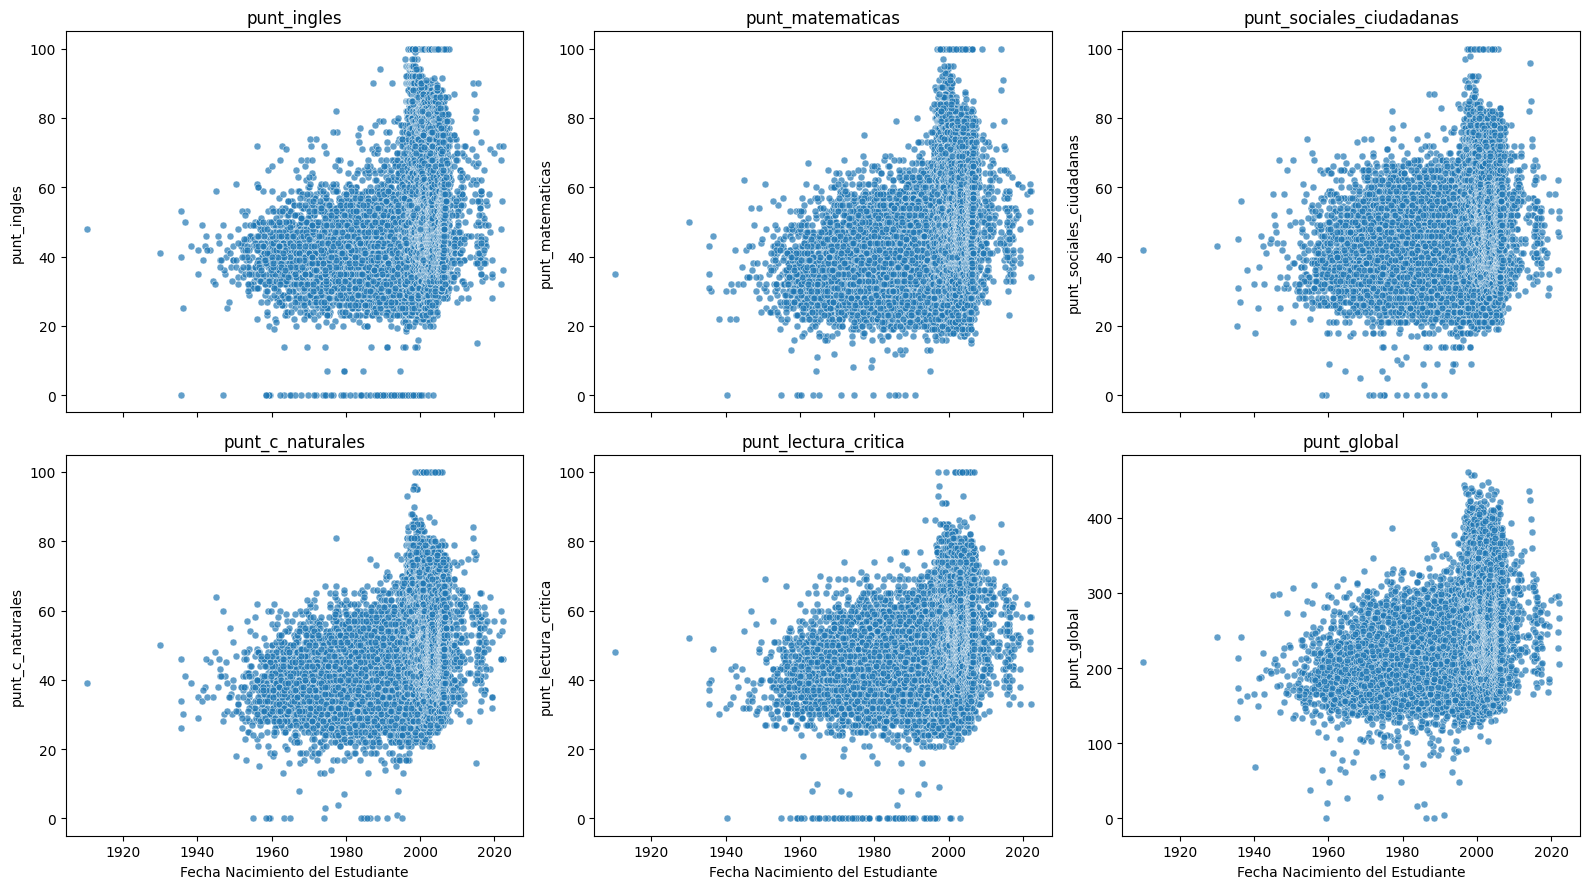

punt_global                 1.000000
punt_c_naturales            0.914806
punt_sociales_ciudadanas    0.911092
punt_matematicas            0.907351
punt_lectura_critica        0.895753
punt_ingles                 0.776458
año                         0.038803
Name: punt_global, dtype: float64


In [84]:


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, puntajes):
    sns.scatterplot(
        data=municipios_agg,
        x="estu_fechanacimiento",
        y=col,
        ax=ax,
        s=25,
        alpha=0.7
    )
    ax.set_title(col)
    ax.set_xlabel("Fecha Nacimiento del Estudiante")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

print(municipios_agg.corr(numeric_only=True)["punt_global"].sort_values(ascending=False))



In [85]:
#sns.violinplot(data=municipios, x="Zona", y="punt_global")
#municipios.groupby("Zona")["punt_global"].mean().plot(kind="barh")
#sns.scatterplot(data=municipios, x="punt_matematicas", y="punt_global", hue="Zona")
top = municipios.groupby(["cole_mcpio_ubicacion"])["punt_global"].mean().sort_values(ascending=False).head(15)
print(top)
#top.plot(kind="line",x="año")
"""
mun = "TULUA"

df_mun = municipios[municipios["cole_mcpio_ubicacion"] == mun]

sns.lineplot(data=df_mun, x="año", y="punt_global")
plt.title(f"Evolución puntaje — {mun}")



sns.lineplot(
    data=municipios,
    x="año",
    y="punt_global",
    hue="cole_mcpio_ubicacion",
    legend=False
)

plt.show()

"""


cole_mcpio_ubicacion
GUADALAJARA DE BUGA    272.476552
PALMIRA                265.732240
CALI                   265.653488
BUGA                   262.996304
GINEBRA                262.759876
TULUA                  259.775159
ROLDANILLO             258.493161
JAMUNDI                257.377953
YUMBO                  256.451252
CALIMA EL DARIEN       255.566474
EL DOVIO               255.129630
SEVILLA                254.055783
CARTAGO                254.054378
LA CUMBRE              252.489891
EL CERRITO             251.745970
Name: punt_global, dtype: float64


'\nmun = "TULUA"\n\ndf_mun = municipios[municipios["cole_mcpio_ubicacion"] == mun]\n\nsns.lineplot(data=df_mun, x="año", y="punt_global")\nplt.title(f"Evolución puntaje — {mun}")\n\n\n\nsns.lineplot(\n    data=municipios,\n    x="año",\n    y="punt_global",\n    hue="cole_mcpio_ubicacion",\n    legend=False\n)\n\nplt.show()\n\n'

In [86]:
municipios.shape


(254015, 10)

In [88]:
puntajes=df.copy()


puntajes["Puntaje area ubicacion"] = puntajes["cole_area_ubicacion"].map({"URBANO": 1, "RURAL": 0})
puntajes["Puntaje bilinguen"] = puntajes["cole_bilingue"].map({"S": 1, "N": 0})
puntajes["Puntaje calendario"] = puntajes["cole_calendario"].map({"A": 1, "B": 2,"OTROS": 3})
puntajes["Puntaje caracter"] = puntajes["cole_caracter"].map({"TÉCNICO/ACADÉMICO": 1, "ACADÉMICO": 2,"TÉCNICO": 3,"NO APLICA": 4})
puntajes["Puntaje Genero col"] = puntajes["cole_genero"].map({"MIXTO": 1, "FEMENINO": 2,"MASCULINO": 3})
puntajes["Puntaje Jornada"] = puntajes["cole_jornada"].map({"MAÑANA": 1, "TARDE": 2,"COMPLETA": 3,"NOCHE": 4,"UNICA": 5,"SABATINA":6})
puntajes["Puntaje Naturaleza"] = puntajes["cole_naturaleza"].map({"OFICIAL": 1, "NO OFICIAL": 0})
puntajes["Puntaje Sede Principal"] = puntajes["cole_sede_principal"].map({"S": 1, "N": 0})
puntajes["Puntaje Investigación"] = puntajes["estu_estadoinvestigacion"].map({"PUBLICAR": 3, "VALIDEZ OFICINA JURÍDICA": 2,"PRESENTE CON LECTURA TARDIA":1,"NO SE COMPROBO IDENTIDAD DEL EXAMINADO":0})
puntajes["Puntaje Genero"] = puntajes["estu_genero"].map({"M": 0, "F": 1})
puntajes["Puntaje Libertad"] = puntajes["estu_privado_libertad"].map({"S": 0, "N": 1})
puntajes["Puntaje Cuartos Hogar"] = puntajes["fami_cuartoshogar"].map({"Uno": 1, "Dos": 2,"Tres": 3,"Cuatro": 4,"Cinco": 5,"Seis":6,"Seis o mas": 6.5,"Siete": 7,"Ocho": 8,"Nueve": 9,"Diez o más": 10})

puntajes["Puntaje Educación Madre"] = puntajes["fami_educacionmadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Educación Padre"] = puntajes["fami_educacionpadre"].map({"No Aplica":0,"No sabe":1,"Ninguno":2,"Primaria incompleta":3,
                                                                           "Primaria completa":4,"Secundaria (Bachillerato) incompleta":5,
                                                                           "Secundaria (Bachillerato) completa":6,"Técnica o tecnológica completa":7,
                                                                           "Técnica o tecnológica incompleta":8,"Educación profesional incompleta":9,
                                                                           "Educación profesional completa":10,"Postgrado":11})

puntajes["Puntaje Personas Hogar"] = puntajes["fami_personashogar"].map({"Una": 1, "1 a 2":1.5,"Dos": 2,"Tres": 3,"3 a 4":3.5,"Cuatro": 4,"Cinco": 5,
                                                                         "5 a 6":5.5,"Seis": 6,"Siete": 7,"7 a 8":7.5,"Ocho": 8,"Nueve": 9,"9 o más":9.5,
                                                                         "Diez": 10,"Doce o más": 10})
puntajes["Puntaje Automóvil"] = puntajes["fami_tieneautomovil"].map({"Si": 1, "No": 0})
puntajes["Puntaje Computador"] = puntajes["fami_tienecomputador"].map({"Si": 1, "No": 0})

puntajes["Puntaje Lavadora"] = puntajes["fami_tienelavadora"].map({"Si": 1, "No": 0})
puntajes["Puntaje Desempeño ingles"] = puntajes["desemp_ingles"].map({"A-":0,"A1": 1, "A2": 2,"B1": 3,"B+": 4})


puntajes["desemp_ingles"].value_counts()

"""

"""


municipiosss= df.copy()


def normalizar(s):
    return (s.str.normalize("NFKD")
                .str.encode("ascii","ignore")
                .str.decode("utf-8").str.upper()
                .str.strip())





puntajes["cole_mcpio_ubicacion"] = (
    df["cole_mcpio_ubicacion"]
    .pipe(normalizar))
puntajes["cole_mcpio_ubicacion"] = puntajes["cole_mcpio_ubicacion"].replace(["CALIMA (DARIEN)", "CALIMA"], "CALIMA EL DARIEN")

mapazonas= {
    # Zona Pacífico 
    "BUENAVENTURA": "Pacífico",

    # Zona Centro
    "CALIMA EL DARIEN": "Centro",
    "YOTOCO": "Centro",
    "SAN PEDRO": "Centro",
    "GUADALAJARA DE BUGA": "Centro",   
    "BUGA": "Centro",                  
    "GUACARI": "Centro",
    "GINEBRA": "Centro",
    "EL CERRITO": "Centro",

    # Zona Sur 
    "DAGUA": "Sur",
    "LA CUMBRE": "Sur",
    "VIJES": "Sur",
    "YUMBO": "Sur",
    "CALI": "Sur",
    "PALMIRA": "Sur",
    "CANDELARIA": "Sur",
    "PRADERA": "Sur",
    "FLORIDA": "Sur",
    "JAMUNDI": "Sur",
    "RESTREPO": "Sur",

    # Zona Norte
    "ALCALA": "Norte",
    "ULLOA": "Norte",
    "CARTAGO": "Norte",
    "ANSERMANUEVO": "Norte",
    "EL AGUILA": "Norte",
    "EL CAIRO": "Norte",
    "VERSALLES": "Norte",
    "ARGELIA": "Norte",
    "TORO": "Norte",
    "OBANDO": "Norte",
    "LA VICTORIA": "Norte",
    "LA UNION": "Norte",
    "ROLDANILLO": "Norte",
    "ZARZAL": "Norte",
    "BOLIVAR": "Norte",
    "TRUJILLO": "Norte",
    "RIOFRIO": "Norte",
    "EL DOVIO": "Norte",
    "ANDALUCIA": "Norte",
    "BUGALAGRANDE": "Norte",
    "TULUA": "Norte",
    "SEVILLA": "Norte",
    "CAICEDONIA": "Norte",
}

puntajes["Zona"] = puntajes["cole_mcpio_ubicacion"].map(mapazonas)
#print(municipios.groupby("Zona").size())
#municipios[municipios["Zona"].isna()]
puntajes.head()

puntajes["año"] = puntajes["año"].astype(int)


puntajess = puntajes.iloc[:, 45:].copy()
"""
puntajess.head()
#puntajess.info()


puntajess.corr(numeric_only=True)


sns.heatmap(puntajess.corr(numeric_only=True), cmap="coolwarm")
puntajess.corr(numeric_only=True)["punt_global"].sort_values(ascending=False)



puntajess[puntajess["Puntaje Automóvil"]==1][["Puntaje Automóvil","punt_global"]].describe()
"""

puntajess["Puntaje educacion padres"] = puntajess["Puntaje Educación Padre"]+puntajess["Puntaje Educación Madre"]
puntajess["Puntaje recursos hogar"] = puntajess["Puntaje Automóvil"]+puntajess["Puntaje Computador"]+puntajess["Puntaje Lavadora"]

puntajess.columns
#sns.scatterplot(data=puntajess, x="Puntaje educacion padres", y="punt_global", hue="Zona")



#print(munivio_agg.corr(numeric_only=True)["indice_violencia"].sort_values(ascending=False))





Index(['punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas',
       'punt_c_naturales', 'punt_lectura_critica', 'punt_global',
       'estrato_num', 'año', 'Puntaje area ubicacion', 'Puntaje bilinguen',
       'Puntaje calendario', 'Puntaje caracter', 'Puntaje Genero col',
       'Puntaje Jornada', 'Puntaje Naturaleza', 'Puntaje Sede Principal',
       'Puntaje Investigación', 'Puntaje Genero', 'Puntaje Libertad',
       'Puntaje Cuartos Hogar', 'Puntaje Educación Madre',
       'Puntaje Educación Padre', 'Puntaje Personas Hogar',
       'Puntaje Automóvil', 'Puntaje Computador', 'Puntaje Lavadora',
       'Puntaje Desempeño ingles', 'Zona', 'Puntaje educacion padres',
       'Puntaje recursos hogar'],
      dtype='object')

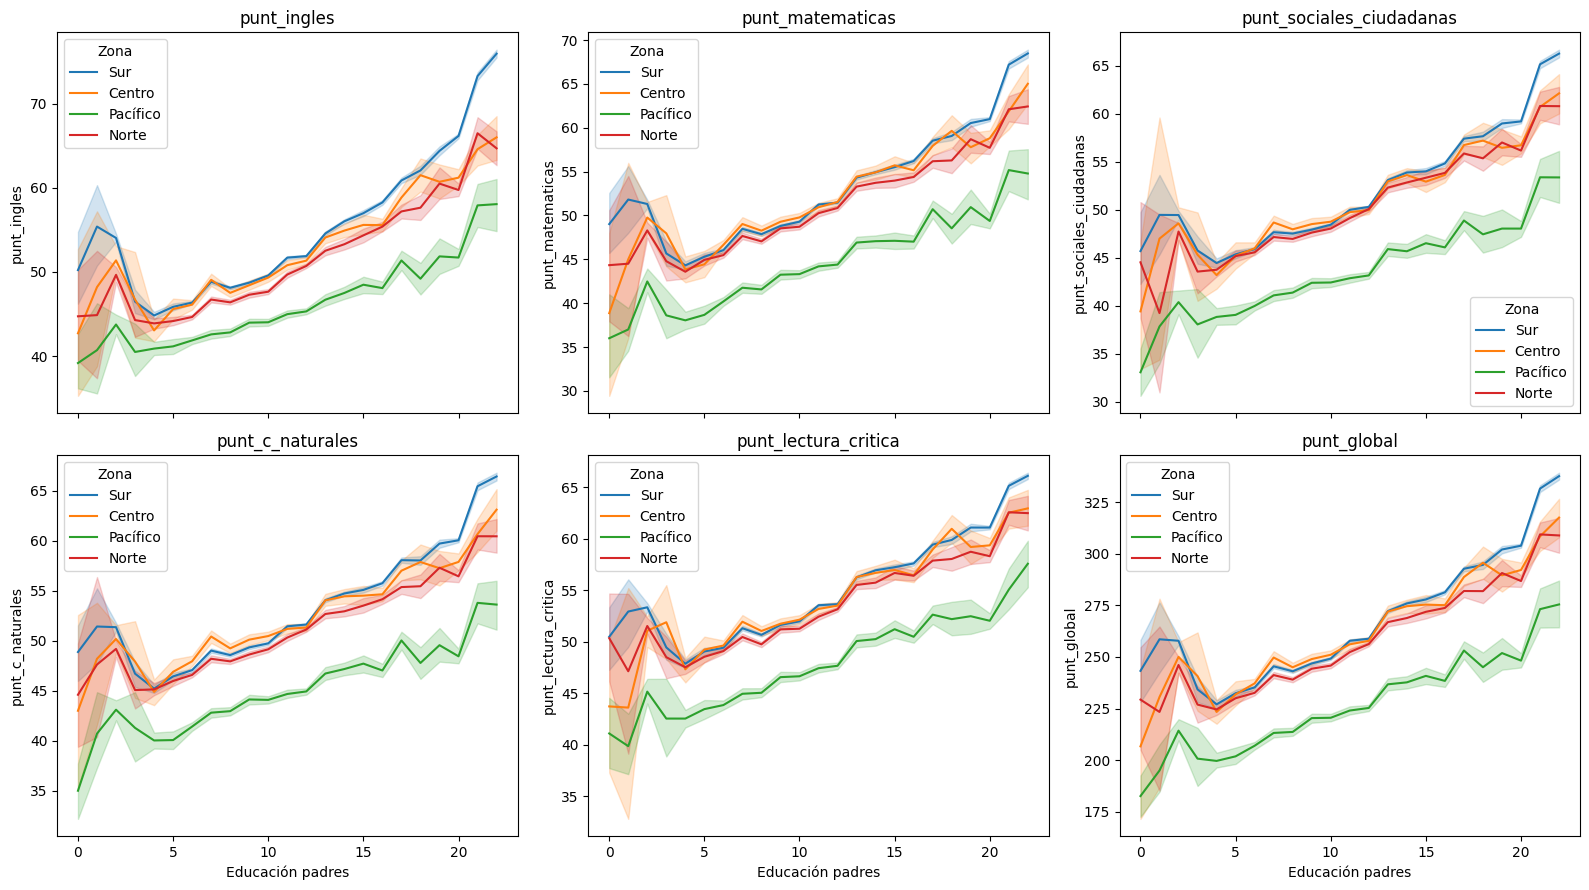

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.flatten()
categorias = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

for ax, col in zip(axes, categorias):
    sns.lineplot(
    data=puntajess,
    x="Puntaje educacion padres",
    y=col,
    ax=ax,
    hue="Zona",
    legend=True
)
    ax.set_title(col)
    ax.set_xlabel("Educación padres")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()